In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/train.csv")
df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9795,9796,CA-2017-125920,21/05/2017,28/05/2017,Standard Class,SH-19975,Sally Hughsby,Corporate,United States,Chicago,Illinois,60610.0,Central,OFF-BI-10003429,Office Supplies,Binders,"Cardinal HOLDit! Binder Insert Strips,Extra St...",3.7980
9796,9797,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,OFF-AR-10001374,Office Supplies,Art,"BIC Brite Liner Highlighters, Chisel Tip",10.3680
9797,9798,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10004977,Technology,Phones,GE 30524EE4,235.1880
9798,9799,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10000912,Technology,Phones,Anker 24W Portable Micro USB Car Charger,26.3760


In [3]:
print(df.shape)
print(df.columns)
print(df.info())

(9800, 18)
Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null 

In [4]:
#Use Customer ID to determine the number of unique customers
df["Customer ID"].nunique()

793

In [5]:
#How much total revenue does each customer generate?
revanue_by_cust = df.groupby("Customer ID")["Sales"].sum()
revanue_by_cust

Customer ID
AA-10315    5563.560
AA-10375    1056.390
AA-10480    1790.512
AA-10645    5086.935
AB-10015     886.156
              ...   
XP-21865    2374.658
YC-21895    5454.350
YS-21880    6720.444
ZC-21910    8025.707
ZD-21925    1493.944
Name: Sales, Length: 793, dtype: float64

In [6]:
#Who are the top 10 customers by total revenue?
revanue_by_cust = df.groupby("Customer ID")["Sales"].sum().sort_values(ascending = False)
revanue_by_cust[0:10]

Customer ID
SM-20320    25043.050
TC-20980    19052.218
RB-19360    15117.339
TA-21385    14595.620
AB-10105    14473.571
KL-16645    14175.229
SC-20095    14142.334
HL-15040    12873.298
SE-20110    12209.438
CC-12370    12129.072
Name: Sales, dtype: float64

In [7]:
#What percentage of the company's total sales comes from the top 10 customers?

perc_total_sales_top10cust = (revanue_by_cust[0:10].sum()/df["Sales"].sum())*100
print(f"Persecantage of company Total sales comes from the top 10 customers : {perc_total_sales_top10cust}")

Persecantage of company Total sales comes from the top 10 customers : 6.8011791882672


In [8]:
#Calculate the number of unique orders for each customer
df.groupby("Customer ID")["Order ID"].nunique()

Customer ID
AA-10315     5
AA-10375     9
AA-10480     4
AA-10645     6
AB-10015     3
            ..
XP-21865    11
YC-21895     5
YS-21880     8
ZC-21910    13
ZD-21925     5
Name: Order ID, Length: 793, dtype: int64

In [20]:
#How many customers are repeat customers?
unique_cust = df.groupby("Customer ID")["Order ID"].nunique().reset_index()
repet_cust = unique_cust[unique_cust["Order ID"]>1]
print(f"Number Of Repeat custmer : {len(repet_cust)}")

Number Of Repeat custmer : 780


In [23]:
#What percentage of customers are repeat customers?
per_of_repet_cust = (len(repet_cust)/len(unique_cust))*100
print(f"Prcentage of repeat custmer : {per_of_repet_cust:.2f}%")

Prcentage of repeat custmer : 98.36%


In [33]:
#How many orders does a typical customer place?
unique_cust["Order ID"].mean()

np.float64(6.206809583858764)

In [26]:
#customers who place more orders generate more revenue?
#average revenue per customer.

avg_total_revanue = df["Sales"].sum()/len(unique_cust)
print(f"Avg revanue Per Custmer : {avg_total_revanue:.2f}")

Avg revanue Per Custmer : 2851.87


In [27]:
#Combine customer orders + revenue
unique_cust = df.groupby("Customer ID")["Order ID"].nunique().reset_index()
unique_cust.rename(columns={'Order ID':'Orders'},inplace=True)
total_revanue = df.groupby("Customer ID")["Sales"].sum().reset_index()

cust_order_revanue = pd.merge(unique_cust,total_revanue,on="Customer ID")
print(cust_order_revanue.head())

  Customer ID  Orders     Sales
0    AA-10315       5  5563.560
1    AA-10375       9  1056.390
2    AA-10480       4  1790.512
3    AA-10645       6  5086.935
4    AB-10015       3   886.156


In [28]:
#customers who place more orders generally generate more revenue?
corelation = cust_order_revanue["Orders"].corr(cust_order_revanue["Sales"])
print(corelation)

0.4193157444096234


In [29]:
#Calculate total sales for each Segment, sorted from highest to lowest.
sales_by_segment =df.groupby("Segment")["Sales"].sum().sort_values(ascending=False).reset_index()
sales_by_segment

,Segment,Sales
0,Consumer,1.148061e+06
1,Corporate,6.884941e+05
2,Home Office,4.249822e+05


In [30]:
#What percentage of total company sales comes from each customer segment?
per_company_sales = (sales_by_segment.set_index("Segment")["Sales"]/df["Sales"].sum())*100
per_company_sales.reset_index()

,Segment,Sales
0,Consumer,50.764619
1,Corporate,30.443638
2,Home Office,18.791743


In [31]:
#Number of unique customers in each Segment
unique_cust = df.groupby("Segment")["Customer ID"].nunique().reset_index()
unique_cust.rename(columns={"Customer ID":"Customer"},inplace=True)
unique_cust

,Segment,Customer
0,Consumer,409
1,Corporate,236
2,Home Office,148


In [32]:
#What is the average revenue per customer for each segment?
avg_revanue_cust = (sales_by_segment.set_index("Segment")["Sales"]/unique_cust.set_index("Segment")["Customer"]).reset_index()
avg_revanue_cust.rename(columns={0:"Revanue"},inplace=True)
avg_revanue_cust

,Segment,Revanue
0,Consumer,2806.993963
1,Corporate,2917.347775
2,Home Office,2871.501195


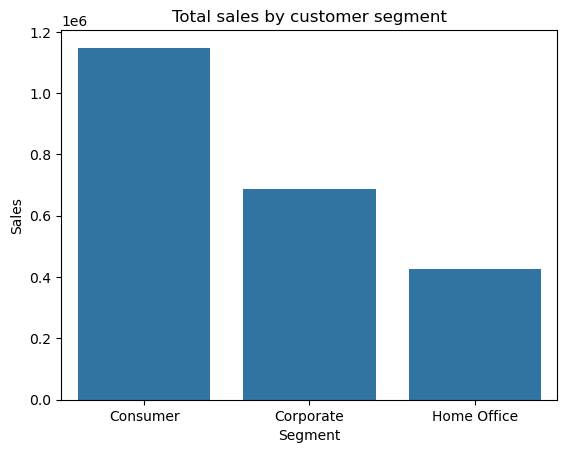

In [33]:
#How much total sales does each customer segment generate?
sns.barplot(x="Segment",y="Sales",data=sales_by_segment)
plt.title("Total sales by customer segment")
plt.xlabel("Segment")
plt.ylabel("Sales")
plt.show()

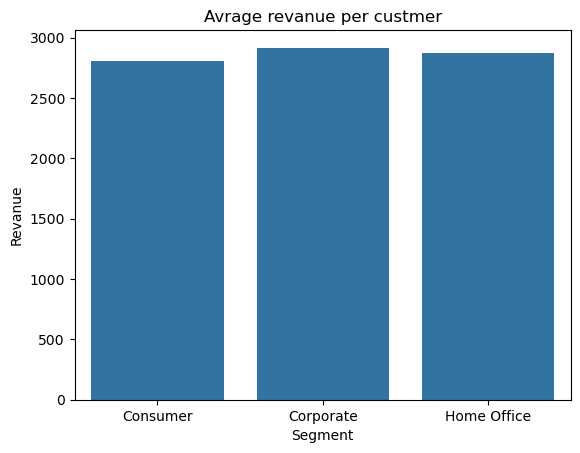

In [34]:
#Which segment has the highest average revenue per customer?
sns.barplot(x="Segment",y="Revanue",data=avg_revanue_cust)
plt.title("Avrage revanue per custmer")
plt.xlabel("Segment")
plt.ylabel("Revanue")
plt.show()

Corporate customers generate the highest average revenue per customer, even though Consumer generates the highest total sales.